<>:26: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipython-input-3371002541.py:26: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega$')


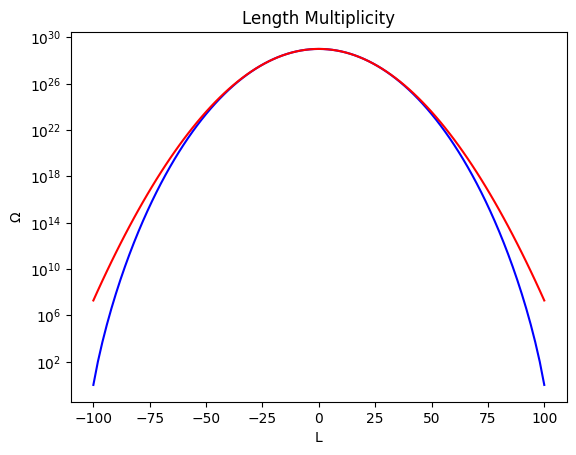

In [ ]:
# Problem 2

import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.special import comb
N = 100 # number of links
d = 1 # length of each link

def num_configurations(L, N, d=1):
  nplus = 0.5 * ((L / d) + N)
  return comb(N, nplus)

L_values = range(-N, N+1, 2)
Omega_values = np.zeros(len(L_values))
theoretical_Omega_values = np.zeros(len(L_values))

for i in range(len(L_values)):
  Omega_values[i] = num_configurations(L_values[i], N, d)
  theoretical_Omega_values[i] = (2**N/np.sqrt(math.pi*N*0.5)*math.exp(-(L_values[i])**2/(2*N*d*d)))

plt.figure()
plt.plot(L_values, Omega_values, color = 'blue')
plt.plot(L_values, theoretical_Omega_values, color = 'red')
plt.xlabel('L')
plt.ylabel('$\Omega$')
plt.title('Length Multiplicity')
plt.yscale('log')
plt.show()

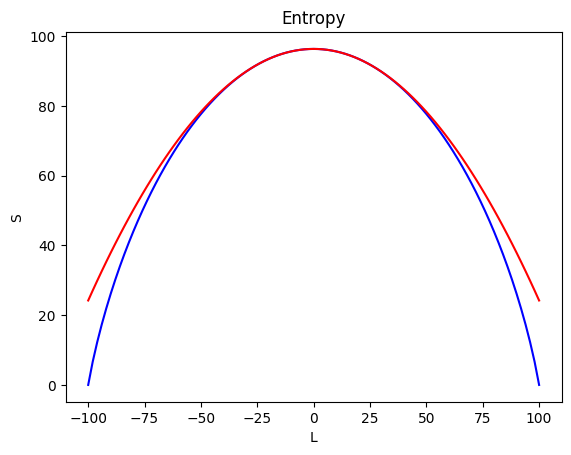

In [ ]:
# Problem 3

def entropy(L, N):
  Omega = num_configurations(L, N, d)
  if Omega == 0:
    return 0
  return math.log(Omega, 2)

S_values = np.zeros(len(L_values))
S_approx = np.zeros(len(L_values))

for i in range(len(L_values)):
  S_values[i] = entropy(L_values[i], N)
for i in range(len(L_values)):
  S_approx[i] = max(S_values) - (L_values[i]**2/(2*N*d*d*math.log(2)))

plt.figure()
plt.plot(L_values, S_values, color = 'blue')
plt.plot(L_values, S_approx, color = 'red')
plt.xlabel('L')
plt.ylabel('S')
plt.title('Entropy')
#plt.yscale('log')
plt.show()

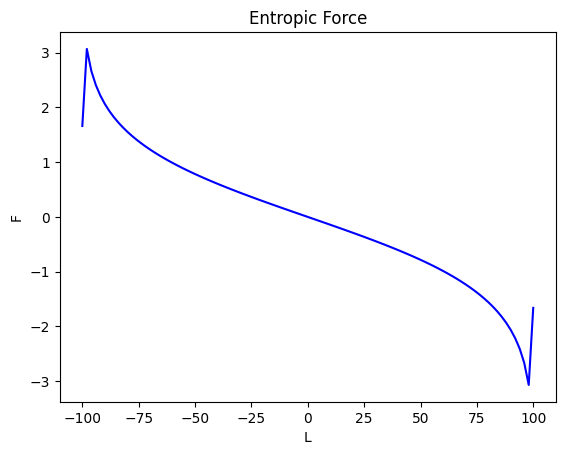

In [ ]:
# Problem 4

def entropic_force(L):
  Splus = entropy(L+2*d, N)
  Sminus = entropy(L-2*d, N)
  return (Splus - Sminus)/(4*d)

F_values = np.zeros(len(L_values))

for i in range(len(L_values)):
  F_values[i] = entropic_force(L_values[i])

plt.figure()
plt.plot(L_values, F_values, color = 'blue')
plt.xlabel('L')
plt.ylabel('F')
plt.title('Entropic Force')
#plt.yscale('log')
plt.show()

Mean:  -0.0046
Standard deviation:  9.993682883550777
Theoretical mean: 0
Theoretical standard deviation:  10.0


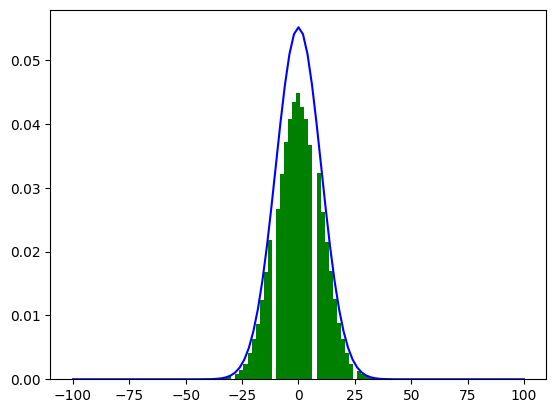

In [20]:
# Problem 5

import statistics

def random_polymer(N):
  links = np.random.choice([-1, 1], size=N)
  return np.sum(links)

polymer_monte_carlo_values = np.zeros(100000)
for i in range(len(polymer_monte_carlo_values)):
  polymer_monte_carlo_values[i] = random_polymer(N)

normal_Omega_values = np.zeros(len(Omega_values))
for i in range(len(Omega_values)):
  normal_Omega_values[i] = Omega_values[i] / (2 ** N) * math.log(2)

mean = statistics.mean(polymer_monte_carlo_values)
sd = statistics.stdev(polymer_monte_carlo_values)

plt.hist(polymer_monte_carlo_values, bins = 50, density = True, color = 'green')
plt.plot(L_values, normal_Omega_values, color = 'blue')

print("Mean: ", mean)
print("Standard deviation: ", sd)
print("Theoretical mean: 0")
print("Theoretical standard deviation: ", d*math.sqrt(N))